In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [3]:
deliveries = pd.read_csv('../data/deliveries.csv')
matches = pd.read_csv('../data/matches.csv')

team_name_map = {
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Kings XI Punjab": "Punjab Kings"
}
deliveries['batting_team'] = deliveries['batting_team'].replace(team_name_map)

df_1st = deliveries[deliveries['inning'] == 1]

team_scores = df_1st.groupby(['match_id', 'batting_team'])['total_runs'].sum().reset_index()

merged_df = pd.merge(team_scores, matches[['id', 'match_type']], left_on='match_id', right_on='id')

merged_df['Stage'] = merged_df['match_type'].apply(lambda x: 'League' if x == 'League' else 'Playoffs')

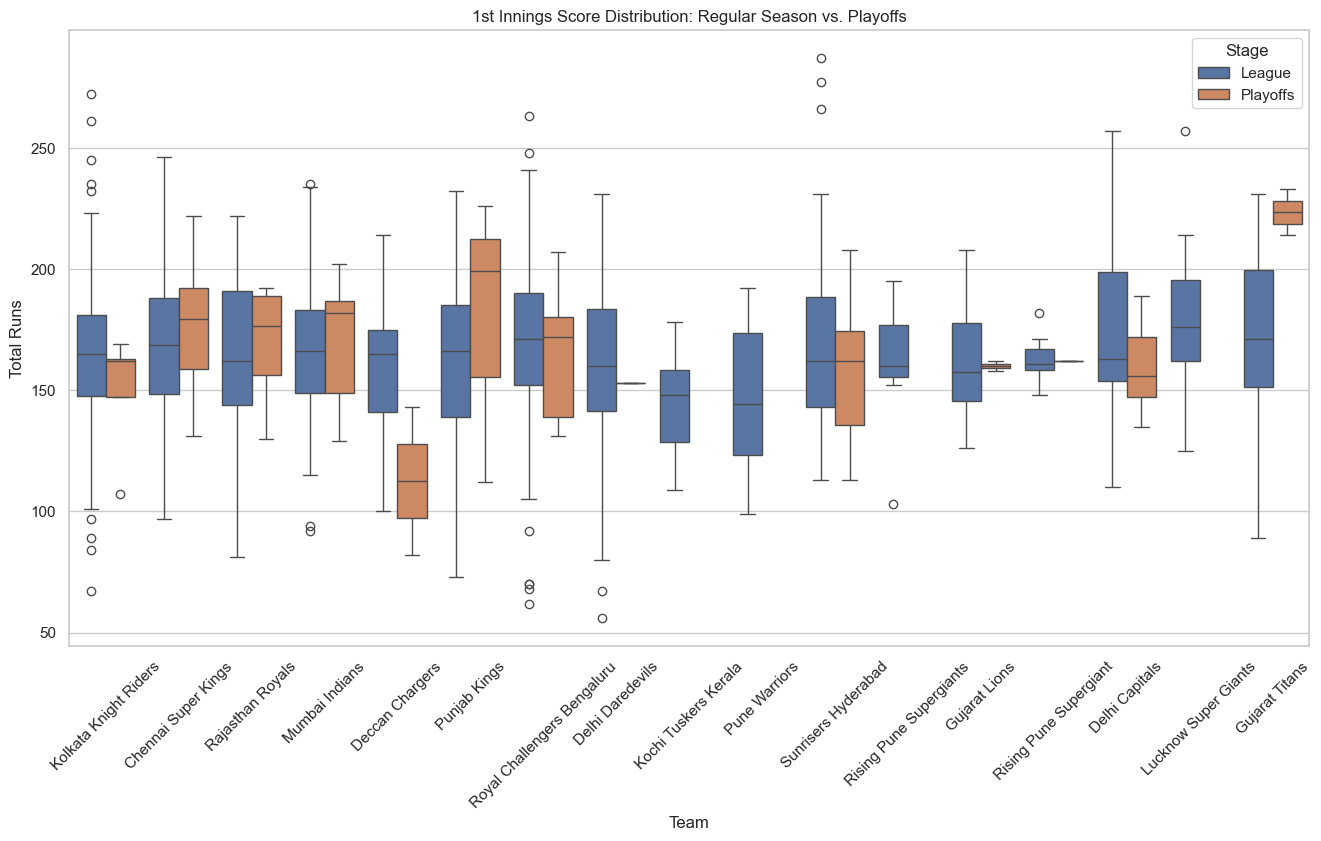

In [4]:
plt.figure(figsize=(16, 8))
sns.boxplot(data=merged_df, x='batting_team', y='total_runs', hue='Stage')

plt.xticks(rotation=45)
plt.title('1st Innings Score Distribution: Regular Season vs. Playoffs')
plt.xlabel('Team')
plt.ylabel('Total Runs')
plt.show()